In [4]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
import astropy.units as u

erg / (s cm2)
Raw aperture flux: 6.650780796576096e-11 erg / (s cm2)
Background per pixel: 1.2400625875274e-16 erg / (s cm2)
Net source flux: 3.1445864331052295e-11 erg / (s cm2)


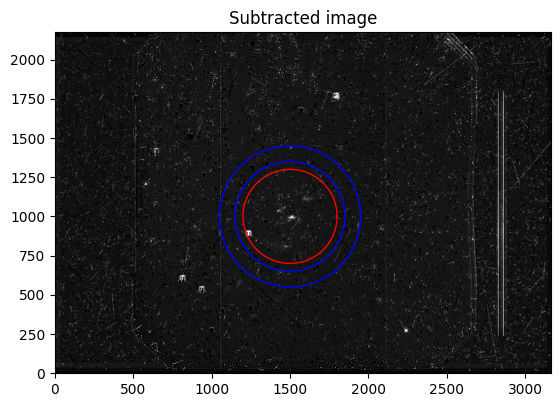

In [25]:
# open the images
oiii_hdu = fits.open("images/normalized_OIII.fits")
oiiic_hdu = fits.open("images/convolved_aligned.fits")

# images
oiii_image = oiii_hdu[0].data * u.electron / u.s
oiiic_image = oiiic_hdu[0].data * u.electron / u.s

# rates from calibration
oiii_slope = 2.917e-14 * u.erg / (u.cm**2 * u.electron)
oiiic_slope = 3.390e-14 * u.erg / (u.cm**2 * u.electron)

# oiii_icpt = 2.455e-13 * u.erg / (u.s * u.cm**2)
# oiiic_icpt = -2.176e-12 * u.erg / (u.s * u.cm**2)

# calibration factor
# scale = 0.3950555310161904
scale = 0.3513827720223936

# scaled images
oiii_flux_image = oiii_image * oiii_slope #+ oiii_icpt
oiiic_flux_image = oiiic_image * oiiic_slope #+ oiiic_icpt




# align images
import astroalign as aa
aligned_oiiic, footprint = aa.register(oiiic_flux_image.value, oiii_flux_image.value)
aligned_oiiic = aligned_oiiic * oiiic_flux_image.unit

# subtract
subtracted_flux_image = oiii_flux_image - scale * aligned_oiiic
print(subtracted_flux_image.unit)

# aperture
from photutils.aperture import CircularAperture, CircularAnnulus, ApertureStats, aperture_photometry
x_center = 1500
y_center = 1000
radius = 300
# aperture = CircularAperture((x_center, y_center), r=radius)
# result = aperture_photometry(subtracted_flux_image, aperture)
# print("Raw flux:", result["aperture_sum"])

aperture = CircularAperture((x_center, y_center), r=300)
annulus = CircularAnnulus((x_center, y_center), r_in=350, r_out=450)

phot = aperture_photometry(subtracted_flux_image, aperture)

annulus_stats = ApertureStats(
    subtracted_flux_image,
    annulus,
    sigma_clip=None
)

background_per_pixel = annulus_stats.median
background_total = background_per_pixel * aperture.area

net_flux = phot["aperture_sum"][0] - background_total

print("Raw aperture flux:", phot["aperture_sum"][0])
print("Background per pixel:", background_per_pixel)
print("Net source flux:", net_flux)

# plot
plt.imshow(subtracted_flux_image, origin="lower", cmap="gray", vmin=np.nanpercentile(subtracted_flux_image.value, 5), vmax=np.nanpercentile(subtracted_flux_image.value, 99.5))
plt.title("Subtracted image")
aperture.plot(color="red")
annulus.plot(color="blue")
fits.writeto("subtracted_flux.fits", subtracted_flux_image.value, overwrite=True)

erg / (s cm2)
Raw aperture flux: 4.772229202570141e-11 erg / (s cm2)
Background per pixel: 1.6630337836947553e-16 erg / (s cm2)
Net source flux: 7.011195679576806e-13 erg / (s cm2)


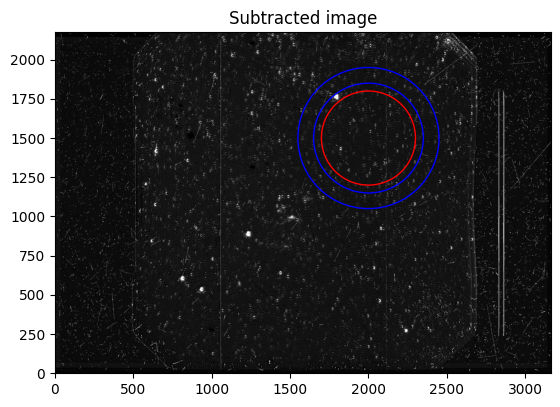

In [ ]:
# # open the images
# oiii_hdu = fits.open("images/normalized_OIII.fits")
# oiiic_hdu = fits.open("images/normalized_OIIIC.fits")

# # images
# oiii_image = oiii_hdu[0].data * u.electron / u.s
# oiiic_image = oiiic_hdu[0].data * u.electron / u.s

# # rates from calibration
# oiii_slope = 2.917e-14 * u.erg / (u.cm**2 * u.electron)
# oiiic_slope = 3.390e-14 * u.erg / (u.cm**2 * u.electron)

# # calibration factor
# # scale = 0.3950555310161904
# scale = 0.34

# # scaled images
# oiii_flux_image = oiii_image * oiii_slope
# oiiic_flux_image = oiiic_image * oiiic_slope


# # align images
# import astroalign as aa
# aligned_oiiic, footprint = aa.register(oiiic_flux_image.value, oiii_flux_image.value)
# aligned_oiiic = aligned_oiiic * oiiic_flux_image.unit

# # subtract
# subtracted_flux_image = oiii_flux_image - scale * aligned_oiiic
# print(subtracted_flux_image.unit)

# # aperture
# from photutils.aperture import CircularAperture, CircularAnnulus, ApertureStats, aperture_photometry
# x_center = 2000
# y_center = 1500
# radius = 300
# # aperture = CircularAperture((x_center, y_center), r=radius)
# # result = aperture_photometry(subtracted_flux_image, aperture)
# # print("Raw flux:", result["aperture_sum"])

# aperture = CircularAperture((x_center, y_center), r=300)
# annulus = CircularAnnulus((x_center, y_center), r_in=350, r_out=450)

# phot = aperture_photometry(subtracted_flux_image, aperture)

# annulus_stats = ApertureStats(
#     subtracted_flux_image,
#     annulus,
#     sigma_clip=None
# )

# background_per_pixel = annulus_stats.median
# background_total = background_per_pixel * aperture.area

# net_flux = phot["aperture_sum"][0] - background_total

# print("Raw aperture flux:", phot["aperture_sum"][0])
# print("Background per pixel:", background_per_pixel)
# print("Net source flux:", net_flux)

# # plot
# plt.imshow(subtracted_flux_image, origin="lower", cmap="gray", vmin=np.nanpercentile(subtracted_flux_image.value, 5), vmax=np.nanpercentile(subtracted_flux_image.value, 99.5))
# plt.title("Subtracted image")
# aperture.plot(color="red")
# annulus.plot(color="blue")
# fits.writeto("subtracted_flux.fits", subtracted_flux_image.value, overwrite=True)

In [7]:
# what if we mask the sources?